# Tuning vLLM on one MI300X

**Model:** `Qwen/Qwen3-30B-A3B` — a Mixture-of-Experts model: ~30B parameters stored, only ~3B
*active* per token. Remember that, it explains the best result of the day.
**Hardware:** 1× AMD Instinct MI300X (gfx942, 192 GB HBM3). Single GPU — no tensor parallelism anywhere.

We start with the command everybody types on day one, measure it, then add flags until it's 3-4×
faster. Same GPU, same model, same weights the whole way.

| Run | Command changes | What you learn |
|---|---|---|
| **A** | plain `vllm serve` | the API, tool calling, reasoning, the startup log, our baseline |
| **B** | `--max-model-len`, `--max-num-seqs`, `--max-num-batched-tokens`, `--gpu-memory-utilization` | sizing the KV cache; prefix caching |
| **C** | FP8 checkpoint + `--kv-cache-dtype fp8` | quantization |
| **C2** | `--cpu-offload-gb` *(optional)* | the flag that looks like free memory and isn't |
| **D** | `--moe-backend aiter` | AMD's MoE kernels |
| **E** | `--linear-backend aiter` + AITER attention | the full AITER stack |
| **F** | `--speculative-config` | guessing tokens ahead |

Runs C, D and E differ by **one flag each**. Same model, same sizing, same workload.

> Two ways to read this: the **bold one-liners** tell you what a flag does. The paragraph after tells
> you why it works. Skip the paragraphs if you're new; they'll still make sense.

---
## Setup

Two checks and one download. Skip to §A if the machine is already prepared.

In [1]:
!amd-smi static -g 0 2>/dev/null | head -12 || rocm-smi --showproductname
!echo "--- NUMA balancing (want 0) ---" && cat /proc/sys/kernel/numa_balancing

GPU: 0
    ASIC:
        MARKET_NAME: AMD Instinct MI355X
        VENDOR_ID: 0x1002
        VENDOR_NAME: Advanced Micro Devices Inc. [AMD/ATI]
        SUBVENDOR_ID: 0x1002
        DEVICE_ID: 0x75a3
        SUBSYSTEM_ID: 0x75a3
        REV_ID: 0x00
        ASIC_SERIAL: 0x83EB8815EBF56B2B
        OAM_ID: 6
        NUM_COMPUTE_UNITS: 256


--- NUMA balancing (want 0) ---
0


If NUMA balancing printed `1`, turn it off — the kernel migrating pages under the GPU shows up as a
hang that looks like a vLLM bug:

```bash
sudo sh -c 'echo 0 > /proc/sys/kernel/numa_balancing'
```

In [2]:
%%bash
# Override with:  export VLLM_IMAGE=vllm/vllm-openai-rocm:nightly-<sha>
IMAGE=${VLLM_IMAGE:-rocm/vllm:latest}
mkdir -p results logs
echo "image: $IMAGE"
docker image inspect "$IMAGE" >/dev/null 2>&1 && echo "already present" || docker pull "$IMAGE"

image: vllm/vllm-openai-rocm:nightly-dc36fcce902a63eab06c1b93a5c4a5ee178a0c56


already present


### Check the image before you trust this notebook

vLLM flag and environment-variable names **change between releases**, and vLLM silently ignores an
environment variable it doesn't recognise — so a stale `-e VLLM_...=1` doesn't error, it just does
nothing, and you'd draw the wrong conclusion from the benchmark.

This cell asks your image directly. Run it first; anything marked `GONE` or `MISS` needs looking up
before the workshop.

In [3]:
%%bash
IMAGE=${VLLM_IMAGE:-rocm/vllm:latest}
docker run --rm --entrypoint "" \
  --device /dev/kfd --device /dev/dri --group-add video --group-add render \
  "$IMAGE" bash -lc '
python3 -c "
import vllm, vllm.envs as e
print(\"vLLM\", vllm.__version__)
print()
print(\"env vars this notebook sets:\")
for k in [\"VLLM_ROCM_USE_AITER\",\"VLLM_ROCM_USE_AITER_MOE\",\"VLLM_ROCM_USE_AITER_MHA\",
          \"VLLM_ROCM_USE_AITER_LINEAR\",\"VLLM_ROCM_USE_AITER_RMSNORM\"]:
    print((\"  OK   \" if hasattr(e,k) else \"  GONE \") + k)
"
echo
echo "serve flags this notebook uses:"
vllm serve --help=all 2>/dev/null > /tmp/h.txt
for f in --kv-cache-dtype --speculative-config --max-num-batched-tokens \
         --gpu-memory-utilization --cpu-offload-gb --attention-backend \
         --moe-backend --linear-backend \
         --tool-call-parser --reasoning-parser --served-model-name; do
  grep -q -- "$f" /tmp/h.txt && echo "  OK   $f" || echo "  MISS $f"
done
echo
echo "bench flags / datasets:"
vllm bench serve --help=all 2>/dev/null > /tmp/b.txt
for f in --num-warmups --tokenizer prefix_repetition --max-concurrency; do
  grep -q -- "$f" /tmp/b.txt && echo "  OK   $f" || echo "  MISS $f"
done
'

vLLM 0.29.1rc1.dev47+gdc36fcce9

env vars this notebook sets:
  OK   VLLM_ROCM_USE_AITER
  OK   VLLM

_ROCM_USE_AITER_MOE
  OK   VLLM_ROCM_USE_AITER_MHA
  OK   VLLM_ROCM_USE_AITER_LINEAR
  OK   VLLM_ROC

M_USE_AITER_RMSNORM



serve flags this notebook uses:


  OK   --kv-cache-dtype


...

  OK   --served-model-name

bench flags / datasets:


  OK   --num-warmups


  OK   --tokenizer


  OK   prefix_repetition


  OK   --max-concurrency


Two notes on what you might see:

- **`--moe-backend` / `--linear-backend` / `--attention-backend`** are the modern way to pick kernels.
  Older builds used environment variables instead (`VLLM_ROCM_USE_AITER_MOE`, `VLLM_ROCM_USE_AITER_MHA`,
  `VLLM_USE_TRITON_FLASH_ATTN`, `VLLM_V1_USE_PREFILL_DECODE_ATTENTION`). If these show `MISS`, your
  image is older — set the equivalent env vars in §D/§E instead, and check the log to confirm they
  actually took effect.
- **`--num-warmups`** is a recent addition to the benchmark CLI. If it's `MISS`, drop the flag and run
  each benchmark twice, ignoring the first.
- `vllm serve --help` needs the GPU devices attached or it can't infer the device type — that's why
  this cell passes `--device` even though it isn't starting a server.

In [4]:
%%bash
# Pre-download both checkpoints (~92 GB). Do this BEFORE the workshop, not during.
# Already cached? This returns in seconds.
IMAGE=${VLLM_IMAGE:-rocm/vllm:latest}
docker run --rm -v ~/.cache/huggingface:/root/.cache/huggingface \
    --entrypoint python3 "$IMAGE" -c \
    "from huggingface_hub import snapshot_download as d; \
     d('Qwen/Qwen3-30B-A3B'); d('Qwen/Qwen3-30B-A3B-FP8')" 2>&1 | tail -2
du -sh ~/.cache/huggingface/hub 2>/dev/null

Fetching 26 files: 100%|█████

█████| 26/26 [00:00<00:00, 2333.81it/s]
Fetching 17 files:   0%|          | 0/17 [00:00<?, 

Fetching 17 files: 100%|██████████| 17/17 [00:00<00:00, 2627.62it/s]


89G	/home/asirra/.cache/huggingface/hub


---
## The Docker command

Every run in this notebook is the same `docker run`, with different `vllm serve` flags on the end.
We split it in two so we can slot `-e` environment variables in the middle later:

```bash
docker run -d --rm --name vllm-server \
    --network host --ipc host \
    --device /dev/kfd --device /dev/dri \
    --group-add video --group-add render \
    --shm-size 16g \
    -e HIP_VISIBLE_DEVICES=0 \
    -v ~/.cache/huggingface:/root/.cache/huggingface \
    -v $PWD/results:/results \
    --entrypoint '' \
    rocm/vllm:latest \
    vllm serve Qwen/Qwen3-30B-A3B --served-model-name qwen --port 8000
```

| Flag | Why it's there |
|---|---|
| `--device /dev/kfd --device /dev/dri` | the AMD kernel driver and render nodes — no GPU in the container without them |
| `--group-add video --group-add render` | permission to open those devices |
| `--ipc host --shm-size 16g` | PyTorch shared memory; too small gives you mystery hangs |
| `--network host` | `localhost:8000` means the same thing inside and out |
| `-v ~/.cache/huggingface` | weights download once, shared by all the runs |
| `-v $PWD/results:/results` | benchmark JSON written inside lands in your folder |
| `-d` | detached — the server runs in the background and the notebook keeps going |
| `-e HIP_VISIBLE_DEVICES=0` | use GPU 0 only. Harmless on a 1-GPU box, essential on a shared multi-GPU node |
| `--entrypoint ''` | see below |

**Why `--entrypoint ''`?** Some images — including `vllm/vllm-openai-rocm` — already set
`ENTRYPOINT ["vllm","serve"]`. Without clearing it our command becomes
`vllm serve vllm serve Qwen/...` and fails. Clearing it lets us write the whole command out
explicitly, which is the point: you can copy any cell below straight into a terminal. It's a harmless
no-op on images that don't set an entrypoint.

**`--served-model-name qwen`** is worth one sentence: run C swaps to a different checkpoint
(`...-FP8`), so pinning the name means every `curl` and every benchmark command below stays identical
across all the runs.

In [5]:
DOCKER = "docker run -d --rm --name vllm-server " \
         "--network host --ipc host " \
         "--device /dev/kfd --device /dev/dri " \
         "--group-add video --group-add render " \
         "--shm-size 16g " \
         "-e HIP_VISIBLE_DEVICES=0 " \
         "-v ~/.cache/huggingface:/root/.cache/huggingface " \
         "-v $PWD/results:/results " \
         "--entrypoint ''"

import os
IMAGE = os.environ.get("VLLM_IMAGE", "rocm/vllm:latest")

print(DOCKER, IMAGE)

docker run -d --rm --name vllm-server --network host --ipc host --device /dev/kfd --device /dev/dri --group-add video --group-add render --shm-size 16g -e HIP_VISIBLE_DEVICES=0 -v ~/.cache/huggingface:/root/.cache/huggingface -v $PWD/results:/results --entrypoint '' vllm/vllm-openai-rocm:nightly-dc36fcce902a63eab06c1b93a5c4a5ee178a0c56


### Two small helpers

**Waiting.** `docker run -d` returns immediately, but the server needs several minutes to load
weights, compile and capture graphs. This polls `/health` and holds the notebook until it's actually
serving, so the cells below never fire early.

Budget realistically: a plain 0.6B model takes ~60 s; 30B bf16 on a cold page cache, or any run with
AITER enabled (it JIT-compiles kernels on first use), can take several minutes. The poll runs for 10
minutes. If it ever times out, just run the cell again — it only polls, it doesn't restart anything.

**Stopping.** Before each new run: save the log, kill the container, and give the driver a moment to
release the HBM before the next server asks for it.

```bash
docker logs vllm-server > logs/<name>.log 2>&1; docker rm -f vllm-server; sleep 5
```

In [6]:
%%writefile wait.sh
#!/bin/bash
# Poll /health for up to 10 minutes.
for i in $(seq 1 300); do
    if curl -sf localhost:8000/health > /dev/null; then
        echo "server ready after $((i*2))s"
        exit 0
    fi
    # bail out early if the container died instead of waiting the full 10 min
    if ! docker ps -q -f name=^vllm-server$ | grep -q .; then
        echo "container exited — last 30 log lines:"; docker logs --tail 30 vllm-server; exit 1
    fi
    sleep 2
done
echo "not up after 10 min — last 30 log lines:"
docker logs --tail 30 vllm-server

Writing wait.sh


---
# A · Plain `vllm serve`

No tuning at all. This works, and it's our baseline.

**What vLLM does when you give it nothing:** it reads the model's config, assumes you want the model's
**full** advertised context length, loads the weights, measures how much memory a forward pass needs,
and turns whatever HBM is left into KV cache. Sensible defaults. Almost never the right ones — watch
which choices it makes, because run B overrides exactly those.

**The three flags we do pass are free.** `--enable-auto-tool-choice`, `--tool-call-parser` and
`--reasoning-parser` change how responses are *parsed*, not how fast they're produced. They carry
through every run below and never affect a single benchmark number. Everything else we add today does.
That distinction — feature flags vs performance flags — is worth holding onto.

In [7]:
!{DOCKER} {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3

8e0af9123862208ed781dab97cb8b680eb4babb96e8d9d8f19cabd4fbdf69769


In [8]:
!bash wait.sh

server ready after 104s


## Talk to it

vLLM speaks the OpenAI API. Anything that talks to OpenAI talks to this by changing one URL.

One Qwen3 quirk worth knowing immediately: **it thinks before answering by default.** For a one-line
question that means your whole token budget goes to thinking and `content` comes back empty. So we
pass `"chat_template_kwargs": {"enable_thinking": false}` here. We turn it back on deliberately in the
reasoning section below.

In [9]:
%%bash
curl -s localhost:8000/v1/chat/completions \
  -H "Content-Type: application/json" \
  -d '{"model":"qwen","messages":[{"role":"user","content":"What is the capital of India?"}],"max_tokens":50,"temperature":0,"chat_template_kwargs":{"enable_thinking":false}}' \
| python3 -c "import json,sys; r=json.load(sys.stdin); print(r['choices'][0]['message']['content']); print('usage:', r['usage'])"

The capital of India is **New Delhi**. It is the seat of the Government of India and houses importan

t institutions such as the Parliament of India, the Rashtrapati Bhavan (Presidential Palace), and th

e Supreme Court.
usage: {'prompt_tokens': 19, 'total_tokens': 66, 'completion_tokens': 47, 'prompt_t

okens_details': None, 'completion_tokens_details': {'reasoning_tokens': 0}}


In [10]:
%%bash
# Streaming — the raw server-sent events your user's browser would receive.
curl -sN localhost:8000/v1/chat/completions \
  -H "Content-Type: application/json" \
  -d '{"model":"qwen","messages":[{"role":"user","content":"Count from 1 to 10."}],"max_tokens":60,"temperature":0,"stream":true,"chat_template_kwargs":{"enable_thinking":false}}' \
| head -8

data: {"id":"chatcmpl-a7addff1acad0aff","object":"chat.completion.chunk","created":1789472510,"model

":"qwen","choices":[{"index":0,"delta":{"role":"assistant","content":""},"logprobs":null,"finish_rea

son":null}],"prompt_token_ids":null,"prompt_text":null}

data: {"id":"chatcmpl-a7addff1acad0aff","ob

ject":"chat.completion.chunk","created":1789472510,"model":"qwen","choices":[{"index":0,"delta":{"co

ntent":"1"},"logprobs":null,"finish_reason":null,"token_ids":null}]}

data: {"id":"chatcmpl-a7addff1

acad0aff","object":"chat.completion.chunk","created":1789472510,"model":"qwen","choices":[{"index":0

,"delta":{"content":","},"logprobs":null,"finish_reason":null,"token_ids":null}]}

data: {"id":"chat

cmpl-a7addff1acad0aff","object":"chat.completion.chunk","created":1789472510,"model":"qwen","choices

":[{"index":0,"delta":{"content":" "},"logprobs":null,"finish_reason":null,"token_ids":null}]}



## Tool calling

**What it does:** you describe a function, the model decides to call it, and you get back a parsed
function name and JSON arguments — instead of a blob of text you'd have to pull apart yourself.

This is how you connect a model to a weather API, a database, or any code you own. The model never
runs anything; it just tells you what it wants called and with which arguments.

That's what `--tool-call-parser hermes` does: Qwen3 writes tool calls in its own text format, and the
parser turns that into a proper `tool_calls` field in the response.

In [11]:
%%bash
curl -s localhost:8000/v1/chat/completions -H "Content-Type: application/json" -d @- <<'JSON' \
| python3 -m json.tool | grep -A9 tool_calls
{
  "model": "qwen",
  "messages": [{"role": "user", "content": "What is the weather in Bengaluru today?"}],
  "tool_choice": "auto",
  "tools": [{
    "type": "function",
    "function": {
      "name": "get_weather",
      "description": "Get the current weather for a city.",
      "parameters": {
        "type": "object",
        "properties": {
          "city": {"type": "string", "description": "City name"},
          "unit": {"type": "string", "enum": ["celsius", "fahrenheit"]}
        },
        "required": ["city"]
      }
    }
  }],
  "max_tokens": 300,
  "temperature": 0
}
JSON

                "tool_calls": [
                    {
                        "id": "chatcmpl-tool-9

35fde6bdd089e65",
                        "type": "function",
                        "function": {


                            "name": "get_weather",
                            "arguments": "{\"city

\": \"Bengaluru\", \"unit\": \"celsius\"}"
                        }
                    }
         

       ],
--
            "finish_reason": "tool_calls",
            "stop_reason": null,
           

 "token_ids": null,
            "routed_experts": null
        }
    ],
    "service_tier": null,
  

  "system_fingerprint": "vllm-0.29.1rc1.dev47+gdc36fcce9-22bf48e2",
    "usage": {
        "prompt_t

okens": 184,


The model read our function description, decided `get_weather` was the right call, and filled in
`city` by itself. Your application reads those arguments, calls the real weather API, and sends the
answer back as another message.

## Reasoning parser

**What it does:** Qwen3 can think step by step before answering. `--reasoning-parser qwen3` puts that
thinking into its own `reasoning_content` field, separate from the answer.

Why you'd want that: you can log the reasoning for debugging, hide it from users, or count those
tokens separately — without it leaking into what you display.

In [12]:
%%bash
curl -s localhost:8000/v1/chat/completions -H "Content-Type: application/json" -d @- <<'JSON' \
| python3 -c "
import json,sys
m = json.load(sys.stdin)['choices'][0]['message']
# vLLM renamed this field: older builds use reasoning_content, newer ones use reasoning.
thinking = m.get('reasoning_content') or m.get('reasoning')
print('--- the thinking ---')
print((thinking or '(empty - check --reasoning-parser)')[:600])
print()
print('--- content (what the user sees) ---')
print((m.get('content') or '')[:400])
"
{
  "model": "qwen",
  "messages": [{"role": "user", "content": "I have 3 boxes with 7 apples in each. I give away 5 apples. How many are left?"}],
  "max_tokens": 1200,
  "temperature": 0,
  "chat_template_kwargs": {"enable_thinking": true}
}
JSON

--- the thinking ---

Okay, let's see. The problem says I have 3 boxes with 7 apples each. So first,

 I need to figure out how many apples I have in total. If each box has 7 apples and there are 3 boxe

s, I should multiply 3 by 7. Let me do that: 3 times 7 is 21. So, 21 apples in total.

Then, I give 

away 5 apples. To find out how many are left, I need to subtract the 5 apples I gave away from the t

otal. So, 21 minus 5. Let me calculate that. 21 minus 5 is 16. Hmm, that seems straightforward. Wait

, is there any chance I might have misread the problem? Let me check again.

The question says 3 box

es with 7 apples each

--- content (what the user sees) ---


You start with 3 boxes, each containin

g 7 apples. 

**Total apples initially:**  
$ 3 \times 7 = 21 $ apples.

**After giving away 5 apple

s:**  
$ 21 - 5 = 16 $ apples.

**Answer:** $\boxed{16}$


Same response, two fields. Everything from here on is about making this faster.

## Read the startup log

This is the most useful thing vLLM prints and almost nobody reads it.

In [13]:
!docker logs vllm-server 2>&1 \
    | grep -iE "Model loading took|Available KV cache memory|GPU KV cache size|Free memory on device|init engine|Graph capturing finished|torch.compile took|Using .* backend" \
    | cut -c1-200 | head -14

(EngineCore pid=602) INFO 09-15 11:40:42 [unquantized.py:319] Using TRITON Unquantized MoE backend out of potential backends: ['ROCm AITER', 'TRITON', 'BATCHED_TRITON'].
(EngineCore pid=602) INFO 09-15 11:41:02 [unquantized.py:401] Using TritonExperts MoE backend
(EngineCore pid=602) INFO 09-15 11:41:02 [model_runner.py:431] Model loading took 56.88 GiB memory and 20.605725 seconds
(EngineCore pid=602) INFO 09-15 11:41:18 [monitor.py:53] torch.compile took 15.24 s in total
(EngineCore pid=602) INFO 09-15 11:41:30 [model_runner.py:1058] Graph capturing finished in 7 secs, took 5.74 GiB
(EngineCore pid=602) INFO 09-15 11:41:31 [gpu_worker.py:638] Available KV cache memory: 198.38 GiB
(EngineCore pid=602) INFO 09-15 11:41:31 [kv_cache_utils.py:2370] GPU KV cache size: 2,166,864 tokens, Maximum concurrency for 40,960 tokens per request: 52.90x
(EngineCore pid=602) INFO 09-15 11:41:46 [model_runner.py:1058] Graph capturing finished in 8 secs, took 5.78 GiB
(EngineCore pid=602) INFO 09-15 11

Three lines matter:

- **`Model loading took …`** — bf16 for ~30B params is about **61 GB** of your 192 GB.
- **`Available KV cache memory: … GiB`** — what was left after weights, activations and CUDA graphs.
- **`GPU KV cache size: … tokens`** — that memory expressed as tokens: how much conversation you can
  hold *in total, across every request at once*. This is the number that limits how many users you
  can serve.
- **`Free memory on device … Actual usage is …`** — the full breakdown of where your HBM went
  (weights, peak activation, CUDA graph pool, KV cache). If you only read one line, read this one.
- **`Maximum concurrency for N tokens per request: X`** — vLLM doing the division for you. If this
  says `4×` and you were planning on 50 concurrent users, you have your answer before writing a load
  test.

Notice `N` in that last line: vLLM assumed the model's **full** context length, because we never told
it otherwise. KV cache per request scales linearly with context length, which is why that concurrency
number is low. Run B fixes it.

## Measure it

Ground rules so all the numbers are comparable: same synthetic dataset, same seed, `--ignore-eos` so
every request generates exactly 256 tokens, and `--num-warmups 32` — 32 throwaway requests sent first
and excluded from the results. Warmup matters more than people expect: the first requests after boot
pay for lazy kernel compilation and allocator warm-up, and we don't want run A charged for that.

*(`--num-warmups` is a recent addition. If your image predates it,
`vllm bench serve --help | grep -i warmup` will tell you, and you can just run the benchmark twice and
ignore the first.)*

In [14]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 1024 --random-output-len 256 \
    --num-prompts 256 --max-concurrency 64 --num-warmups 32 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 01-baseline.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x742d4d757a60>, trust_remote_code=False, seed=1234, num_prompts=256, dataset_name='random', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=256, random_range_ratio='0.0', random_prefix_len=0, random_batch_

  0%|          | 0/32 [00:00<?, ?it/s]WARNING: vllm bench serve no longer sets temperature==0 (greedy) in requests by default. The default will be determined on the server side and can be model/API specific. For the old behavior, include --temperature=0.
Starting initial single prompt test run...
Skipping endpoint ready check.
Warming up with 32 requests...


100%|██████████| 32/32 [00:03<00:00,  8.22it/s]
Warmup run completed.
Starting main benchmark run...
Traffic request rate: inf
Burstiness factor: 1.0 (Poisson process)
Maximum request concurrency: 64
  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 1/256 [00:04<20:46,  4.89s/it]

 20%|█▉        | 50/256 [00:06<00:19, 10.64it/s]

...

 55%|█████▍    | 140/256 [00:14<00:11, 10.33it/s]

 67%|██████▋   | 172/256 [00:14<00:04, 17.03it/s]

 75%|███████▌  | 193/256 [00:18<00:06, 10.43it/s]

100%|██████████| 256/256 [00:18<00:00, 13.86it/s]


tip: install termplotlib and gnuplot to plot the metrics
============ Serving Benchmark Result ============
Successful requests:                     256       
Failed requests:                         0         
Maximum request concurrency:             64        
Benchmark duration (s):                  18.48     
Total input tokens:                      262144    
Total generated tokens:                  65536     
Request throughput (req/s):              13.86     
Output token throughput (tok/s):         3547.01   
Peak output token throughput (tok/s):    4864.00   
Peak concurrent requests:                128.00    
Total token throughput (tok/s):          17735.03  
---------------Time to First Token----------------
Mean TTFT (ms):                          772.67    
Median TTFT (ms):                        633.21    
P99 TTFT (ms):                           1563.71   
-----Time per Output Token (excl. 1st token)------
Mean TPOT (ms):                          15.05     
Median TPO

**Reading that table:** *output throughput* is tokens/second across everyone — the headline number.
*TTFT* is how long before the user sees anything. *TPOT* is how fast it then streams. These three
trade against each other; tuning is choosing where on that curve you sit, not finding one "fast"
setting.

---
# B · Size it for your workload

Four flags. In practice you always set them together.

**`--max-model-len 8192`** — cap the context length at what your requests actually need.
KV cache per request scales linearly with this, so cutting it from 32k to 8k roughly quadruples how
many requests fit. Set it from your real p99 prompt+output length, not from the model card.

**`--max-num-seqs 256`** — how many requests can be in the batch at once. vLLM uses *continuous
batching*: it re-forms the batch every step, so finished requests drop out and new ones join
mid-flight. Raise this until throughput stops improving.

**`--max-num-batched-tokens 8192`** — the token budget per step, shared between processing new prompts
and generating for existing requests. This is the **TTFT ↔ smoothness dial**: a big budget chews
through prompts fast (good TTFT) but stalls the tokens streaming to everyone already connected. Small
budget, the reverse.

**`--gpu-memory-utilization 0.92`** — how much HBM vLLM may claim. This is a real performance dial,
not a safety knob. Every point you leave unused is KV cache you don't get.

### What to watch — and what *not* to expect

The thing these flags change is **capacity**, so read the startup log, not the throughput number.
Compare the `Maximum concurrency` line before and after; on our run it went from `52.90x` to
`267.20x` — five times as many simultaneous requests, from the same GPU and the same weights, purely
because we stopped reserving 40k of context per request when we only need 8k.

**Throughput may not move at all here, and that's the correct result.** Our benchmark drives 64
concurrent requests. Run A already had room for ~53, so we were never short of KV cache at this load —
and capacity you weren't short of buys you nothing. The payoff arrives when concurrency approaches the
ceiling: at 64 requests you see little, at 250+ run A starts queueing and run B doesn't.

What *does* move immediately is **TTFT** (ours: 633 ms → 351 ms), because shorter contexts mean less
prefill work per request.

If you have time, re-run the benchmark below with `--max-concurrency 256` on both configs — that's the
load where the concurrency number stops being a log line and starts being throughput.

In [15]:
!docker logs vllm-server > logs/01-baseline.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [16]:
!{DOCKER} {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92

eec37b04cb83516e255ec55cf7afa3dec8762bc9fce549693fc71886f5339137


In [17]:
!bash wait.sh

server ready after 104s


In [18]:
%%bash
echo "=== A: defaults ==="
grep -iE "GPU KV cache size" logs/01-baseline.log | cut -c1-200 | head -2
echo
echo "=== B: sized ==="
docker logs vllm-server 2>&1 | grep -iE "GPU KV cache size" | cut -c1-200 | head -2
echo
echo "Same GPU, same weights. We just stopped reserving context nobody asked for."

=== A: defaults ===


(EngineCore pid=602) INFO 09-15 11:41:31 [kv_cache_utils.py:2370] GPU KV cache size: 2,166,864 token

s, Maximum concurrency for 40,960 tokens per request: 52.90x



=== B: sized ===


(EngineCore pid=602) INFO 09-15 11:43:56 [kv_cache_utils.py:2370] GPU KV cache size: 2,188,896 token

s, Maximum concurrency for 8,192 tokens per request: 267.20x



Same GPU, same weights. We just stopped reserving context nobody asked for.


In [19]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B --dataset-name random \
    --random-input-len 1024 --random-output-len 256 \
    --num-prompts 256 --max-concurrency 64 --num-warmups 32 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 02-sized.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7134dd153a60>, trust_remote_code=False, seed=1234, num_prompts=256, dataset_name='random', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=256, random_range_ratio='0.0', random_prefix_len=0, random_batch_

Starting initial single prompt test run...
Skipping endpoint ready check.
Warming up with 32 requests...
  0%|          | 0/32 [00:00<?, ?it/s]

  3%|▎         | 1/32 [00:03<01:59,  3.84s/it]

100%|██████████| 32/32 [00:03<00:00,  8.31it/s]
Warmup run completed.
Starting main benchmark run...
Traffic request rate: inf
Burstiness factor: 1.0 (Poisson process)
Maximum request concurrency: 64
  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 1/256 [00:05<25:06,  5.91s/it]

...

 68%|██████▊   | 173/256 [00:14<00:04, 18.96it/s]

 72%|███████▏  | 184/256 [00:14<00:03, 23.35it/s]

 76%|███████▌  | 195/256 [00:18<00:06,  8.87it/s]

100%|██████████| 256/256 [00:18<00:00, 14.05it/s]


tip: install termplotlib and gnuplot to plot the metrics
============ Serving Benchmark Result ============
Successful requests:                     256       
Failed requests:                         0         
Maximum request concurrency:             64        
Benchmark duration (s):                  18.22     
Total input tokens:                      262144    
Total generated tokens:                  65536     
Request throughput (req/s):              14.05     
Output token throughput (tok/s):         3596.87   
Peak output token throughput (tok/s):    5056.00   
Peak concurrent requests:                128.00    
Total token throughput (tok/s):          17984.34  
---------------Time to First Token----------------
Mean TTFT (ms):                          690.75    
Median TTFT (ms):                        351.07    
P99 TTFT (ms):                           2500.64   
-----Time per Output Token (excl. 1st token)------
Mean TPOT (ms):                          15.11     
Median TPO

## Prefix caching — already on, easy to misjudge

**What it does:** if two requests start with the same text — a shared system prompt, a retrieved
document, a few-shot preamble, an agent's conversation history — vLLM reuses the first request's work
instead of recomputing it.

**It's on by default.** There's no flag to add; on the V1 engine prefix caching is enabled for every
supported model. (`--no-enable-prefix-caching` turns it off, which you'd only want for strict
multi-tenant isolation, or a workload where nothing is ever shared so the hash lookup is pure
overhead.)

**Why it helps:** the saving is entirely in the prompt-processing phase, so it shows up as a TTFT
collapse, not as faster streaming.

**The part people get wrong:** the benefit is a property of your *workload*, not your server. So we
won't measure it with the `random` dataset — we'll use `prefix_repetition`, which vLLM ships
specifically for this:

| Flag | Meaning |
|---|---|
| `--prefix-repetition-prefix-len 2048` | 2048 shared tokens at the front of each prompt |
| `--prefix-repetition-suffix-len 128` | 128 unique tokens after it |
| `--prefix-repetition-num-prefixes 4` | how many *distinct* prefixes exist across the run |
| `--prefix-repetition-output-len 128` | tokens generated per request |

`num-prefixes` is the dial. With 128 requests and **4** prefixes, 32 requests share each one — that's
a RAG or agent workload. With **128** prefixes, every request is unique — that's one-off queries.
Identical token counts either way, so any difference is the cache and nothing else. The two runs
generate different prefixes, so neither can hit the other's cache entries.

In [20]:
%%bash
echo "########## HIGH reuse — 4 prefixes shared across 128 requests ##########"
docker exec vllm-server vllm bench serve --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name prefix_repetition \
    --num-prompts 128 --max-concurrency 16 \
    --prefix-repetition-prefix-len 2048 \
    --prefix-repetition-suffix-len 128 \
    --prefix-repetition-num-prefixes 4 \
    --prefix-repetition-output-len 128 \
    2>&1 | grep -E "Output token throughput|Mean TTFT|Median TTFT"

########## HIGH reuse — 4 prefixes shared across 128 requests ##########


Output token throughput (tok/s):         1806.76   
Mean TTFT (ms):                          107.11 

   
Median TTFT (ms):                        101.15    


In [21]:
%%bash
echo "########## NO reuse — 128 prefixes across 128 requests ##########"
docker exec vllm-server vllm bench serve --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name prefix_repetition \
    --num-prompts 128 --max-concurrency 16 \
    --prefix-repetition-prefix-len 2048 \
    --prefix-repetition-suffix-len 128 \
    --prefix-repetition-num-prefixes 128 \
    --prefix-repetition-output-len 128 \
    2>&1 | grep -E "Output token throughput|Mean TTFT|Median TTFT"

########## NO reuse — 128 prefixes across 128 requests ##########


Output token throughput (tok/s):         1291.40   
Mean TTFT (ms):                          273.60 

   
Median TTFT (ms):                        260.09    


In [22]:
# The server's own accounting — hit rate should mirror what you just saw.
!curl -s localhost:8000/metrics | grep -i prefix_cache | grep -v "^#"

vllm:prefix_cache_queries_total{engine="0",model_name="qwen"} 851969.0
vllm:prefix_cache_queries_created{engine="0",model_name="qwen"} 1.7894726517611642e+09
vllm:prefix_cache_hits_total{engine="0",model_name="qwen"} 289376.0
vllm:prefix_cache_hits_created{engine="0",model_name="qwen"} 1.7894726517611744e+09
vllm:external_prefix_cache_queries_total{engine="0",model_name="qwen"} 0.0
vllm:external_prefix_cache_queries_created{engine="0",model_name="qwen"} 1.789472651761186e+09
vllm:external_prefix_cache_hits_total{engine="0",model_name="qwen"} 0.0
vllm:external_prefix_cache_hits_created{engine="0",model_name="qwen"} 1.7894726517611973e+09
vllm:cache_config_info{_block_size_resolved="True",block_size="16",cache_dtype="auto",enable_mamba_fine_grained_prefix_cache="False",enable_prefix_caching="True",engine="0",gpu_memory_utilization="0.92",is_attention_free="False",kv_cache_dtype_skip_layers="[]",kv_cache_layout="None",kv_cache_max_concurrency="267.19921875",kv_cache_memory_bytes="None",kv

**What about a real agent trace?** There's no SWE-bench loader in `vllm bench serve` — the `hf`
dataset path covers a fixed list (VisionArena, InstructCoder, the AI-MO math sets and similar), and
SWE-bench isn't on it. If you want genuine agentic prefix behaviour you have two options: export your
own traces and feed them through `--dataset-name custom`, or look at SGLang's `agentic-trace` dataset,
which replays multi-turn OpenHands/SWE-smith traces round by round. For teaching the mechanism,
`prefix_repetition` is clearer anyway — you control the reuse rate directly instead of inferring it.

---
# C · FP8 weights and FP8 KV cache

Two changes, same target: memory.

**`Qwen/Qwen3-30B-A3B-FP8`** — the same model with weights and activations pre-quantized to 8-bit.
~61 GB becomes ~31 GB. That freed 30 GB doesn't sit idle; it becomes KV cache. And MI300X has native
FP8 (OCP e4m3) matrix cores, so this is a real compute path, not a memory trick with a dequantize
step bolted in front.

**`--kv-cache-dtype fp8`** — halve the bytes per cached token, so the same memory holds ~2× the
tokens. Unlike everything else in this notebook, **this one is lossy.** Measure your accuracy before
shipping it.

### What to watch

Again: read the log, not the throughput. Three numbers move, and they tell the whole story.

| | B (bf16) | C (FP8 + FP8 KV) |
|---|---|---|
| `Model loading took` | 56.88 GiB | **29.14 GiB** — weights halved |
| `Available KV cache memory` | 200.4 GiB | **228.27 GiB** — the freed weight memory became KV |
| `GPU KV cache size` | 2,188,896 tokens | **4,986,624 tokens** — 2.3×, because each token costs half |
| `Maximum concurrency` | 267.20x | **608.72x** |

The two effects compound: smaller weights leave more room, *and* each token in that room costs half.
That is why the token count more than doubles while the memory only grows by 14%.

As in run B, throughput at 64 concurrent requests will barely budge — we are nowhere near needing
600× concurrency. What you've bought is headroom, and headroom is what lets you raise
`--max-num-seqs` and serve more users on the same card.

### A word on FP4 — not on this GPU

MI300X has no native FP4/MXFP4 datapath; that's gfx950 (MI350/MI355). An MXFP4 checkpoint here runs by
dequantizing to bf16 or through emulation — you'd save memory and *lose* throughput. FP4 is the right
answer on the next generation, not this one.

### Why AITER is explicitly off here

We pin the kernels to Triton for this run. That makes run C do double duty: it's the quantization
result, *and* it's the zero point of the kernel ladder in §D–E.

In [23]:
!docker logs vllm-server > logs/02-sized.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [24]:
!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=0 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92 \
        --kv-cache-dtype fp8 \
        --moe-backend triton \
        --linear-backend triton \
        --attention-backend TRITON_ATTN

6c3e6503bac059370c30bf7e132d88981a59352226d10ad27c06fb7963160276


In [25]:
!bash wait.sh

server ready after 102s


In [26]:
%%bash
echo "=== B: bf16 weights, bf16 KV ==="
grep -iE "Model loading took|Available KV cache memory|GPU KV cache size" logs/02-sized.log | cut -c1-200 | head -3
echo
echo "=== C: fp8 weights, fp8 KV ==="
docker logs vllm-server 2>&1 | grep -iE "Model loading took|Available KV cache memory|GPU KV cache size" | cut -c1-200 | head -3

=== B: bf16 weights, bf16 KV ===


(EngineCore pid=602) INFO 09-15 11:43:27 [model_runner.py:431] Model loading took 56.88 GiB memory a

nd 20.570049 seconds
(EngineCore pid=602) INFO 09-15 11:43:56 [gpu_worker.py:638] Available KV cache

 memory: 200.4 GiB
(EngineCore pid=602) INFO 09-15 11:43:56 [kv_cache_utils.py:2370] GPU KV cache si

ze: 2,188,896 tokens, Maximum concurrency for 8,192 tokens per request: 267.20x



=== C: fp8 weights, fp8 KV ===


(EngineCore pid=625) INFO 09-15 11:46:23 [model_runner.py:431] Model loading took 29.14 GiB memory a

nd 14.850665 seconds
(EngineCore pid=625) INFO 09-15 11:46:55 [gpu_worker.py:638] Available KV cache

 memory: 228.27 GiB
(EngineCore pid=625) INFO 09-15 11:46:55 [kv_cache_utils.py:2370] GPU KV cache s

ize: 4,986,624 tokens, Maximum concurrency for 8,192 tokens per request: 608.72x


In [27]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B --dataset-name random \
    --random-input-len 1024 --random-output-len 256 \
    --num-prompts 256 --max-concurrency 64 --num-warmups 32 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 03-fp8.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7e64fd74fb00>, trust_remote_code=False, seed=1234, num_prompts=256, dataset_name='random', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=256, random_range_ratio='0.0', random_prefix_len=0, random_batch_

  0%|          | 0/32 [00:00<?, ?it/s]WARNING: vllm bench serve no longer sets temperature==0 (greedy) in requests by default. The default will be determined on the server side and can be model/API specific. For the old behavior, include --temperature=0.
Starting initial single prompt test run...
Skipping endpoint ready check.
Warming up with 32 requests...


100%|██████████| 32/32 [00:04<00:00,  6.94it/s]
Warmup run completed.
Starting main benchmark run...
Traffic request rate: inf
Burstiness factor: 1.0 (Poisson process)
Maximum request concurrency: 64
  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 1/256 [00:05<25:02,  5.89s/it]

  7%|▋         | 18/256 [00:06<00:57,  4.17it/s]

...

 69%|██████▉   | 176/256 [00:14<00:04, 19.85it/s]

 74%|███████▍  | 189/256 [00:14<00:02, 23.38it/s]

 78%|███████▊  | 200/256 [00:18<00:05,  9.40it/s]

100%|██████████| 256/256 [00:18<00:00, 13.86it/s]


tip: install termplotlib and gnuplot to plot the metrics
============ Serving Benchmark Result ============
Successful requests:                     256       
Failed requests:                         0         
Maximum request concurrency:             64        
Benchmark duration (s):                  18.47     
Total input tokens:                      262144    
Total generated tokens:                  65536     
Request throughput (req/s):              13.86     
Output token throughput (tok/s):         3547.34   
Peak output token throughput (tok/s):    5056.00   
Peak concurrent requests:                128.00    
Total token throughput (tok/s):          17736.72  
---------------Time to First Token----------------
Mean TTFT (ms):                          862.81    
Median TTFT (ms):                        453.64    
P99 TTFT (ms):                           2774.37   
-----Time per Output Token (excl. 1st token)------
Mean TPOT (ms):                          14.68     
Median TPO

In [28]:
# Proof the flag took effect — this line must change between C, D and E.
!docker logs vllm-server 2>&1 | grep -iE "MoE backend|selected via --attention-backend|Selected .*Kernel" | cut -c1-165 | head -5

(EngineCore pid=625) INFO 09-15 11:46:09 [__init__.py:711] Selected TritonFp8BlockScaledMMKernel for Fp8LinearMethod
(EngineCore pid=625) INFO 09-15 11:46:09 [rocm.py:628] Using TRITON_ATTN backend (selected via --attention-backend).
(EngineCore pid=625) INFO 09-15 11:46:09 [fp8.py:359] Using TRITON Fp8 MoE backend out of potential backends: ['AITER', 'FLASHINFER_TRTLLM', 'FLASHINFER_CUTLASS', 'D


---
# C2 · CPU offload — optional, and a useful disappointment

*Adds ~5 minutes. Skip it if you're running short — but it's a good one to leave in, because it's the
only flag here that makes things **worse**.*

**`--cpu-offload-gb 16`** parks 16 GiB of model weights in host RAM instead of HBM. Think of it as a
virtual GPU-memory extender: with a 24 GB card and `--cpu-offload-gb 10`, you can serve as if you had
34 GB.

**Why we don't need it:** our FP8 model is ~31 GB in a 192 GB GPU. There is nothing to offload. We're
turning it on *deliberately* to measure the cost — because the flag reads like free memory, and people
reach for it when they shouldn't.

**What it costs:** every offloaded weight crosses PCIe on every forward pass. Host-to-GPU bandwidth is
orders of magnitude below HBM, and unlike newer prefetch-based offload configs, `--cpu-offload-gb`
doesn't hide the transfer behind compute. Expect the throughput to fall off a cliff.

**The rule:** use it only when the model genuinely does not fit. Reach for quantization first, then a
smaller `--max-model-len`, then a bigger `--gpu-memory-utilization`. Offload is the last resort, not a
tuning knob.

**Two things to know before you try it in anger:**

- It offloads **weights**, not KV cache. Those are different problems with different fixes — if you're
  short on KV cache for long contexts, that's `--swap-space` and the KV-offload connectors, not this.
- It reportedly consumes closer to **1.9×** the host RAM you ask for, because pinned allocations get
  rounded up to the next power of two. Budget accordingly.

In [29]:
!docker logs vllm-server > logs/03-fp8.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [30]:
# Identical to run C, plus one flag.
!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=0 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92 \
        --kv-cache-dtype fp8 \
        --moe-backend triton \
        --linear-backend triton \
        --attention-backend TRITON_ATTN \
        --cpu-offload-gb 16

0e5a25a04d02a8ffbda795e6040f4cec2e17821ca044245d6a26ee194aad913c


In [31]:
!bash wait.sh

server ready after 108s


In [32]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B --dataset-name random \
    --random-input-len 1024 --random-output-len 256 \
    --num-prompts 128 --max-concurrency 64 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 04-cpu-offload.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7a0652740040>, trust_remote_code=False, seed=1234, num_prompts=128, dataset_name='random', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=256, random_range_ratio='0.0', random_prefix_len=0, random_batch_

  0%|          | 0/16 [00:00<?, ?it/s]WARNING: vllm bench serve no longer sets temperature==0 (greedy) in requests by default. The default will be determined on the server side and can be model/API specific. For the old behavior, include --temperature=0.
Starting initial single prompt test run...
Skipping endpoint ready check.
Warming up with 16 requests...


  6%|▋         | 1/16 [00:23<05:53, 23.55s/it]

100%|██████████| 16/16 [00:23<00:00,  1.48s/it]
Warmup run completed.
Starting main benchmark run...
Traffic request rate: inf
Burstiness factor: 1.0 (Poisson process)
Maximum request concurrency: 64
  0%|          | 0/128 [00:00<?, ?it/s]

  1%|          | 1/128 [01:34<3:19:16, 94.14s/it]

...

 78%|███████▊  | 100/128 [03:11<00:13,  2.07it/s]

 84%|████████▍ | 108/128 [03:11<00:06,  3.03it/s]

 91%|█████████ | 116/128 [03:11<00:02,  4.34it/s]

100%|██████████| 128/128 [03:11<00:00,  1.50s/it]


tip: install termplotlib and gnuplot to plot the metrics
============ Serving Benchmark Result ============
Successful requests:                     128       
Failed requests:                         0         
Maximum request concurrency:             64        
Benchmark duration (s):                  191.59    
Total input tokens:                      131072    
Total generated tokens:                  32768     
Request throughput (req/s):              0.67      
Output token throughput (tok/s):         171.03    
Peak output token throughput (tok/s):    256.00    
Peak concurrent requests:                76.00     
Total token throughput (tok/s):          855.14    
---------------Time to First Token----------------
Mean TTFT (ms):                          8455.13   
Median TTFT (ms):                        6901.10   
P99 TTFT (ms):                           18933.05  
-----Time per Output Token (excl. 1st token)------
Mean TPOT (ms):                          341.13    
Median TPO

Compare that to run C. Same model, same flags, one addition — and it's the only bar in today's chart
that points the wrong way. That's the lesson: a flag that buys you capacity is not a flag that buys
you speed, and the two are easy to confuse when you're reading a list of options.

---
# D & E · The AMD part — Triton kernels vs AITER

This is the section that only applies on AMD, and it's the interesting one.

vLLM's default kernels are written in Triton and run everywhere. AMD ships **AITER**, a library of
hand-tuned kernels for Instinct GPUs. The usual demo flips one switch and reports one number. That
tells you *that* it got faster, not *why* — so it doesn't transfer to the next model you deploy.

AITER isn't one switch. It's a family, and vLLM lets you pick each family independently:

| Flag | Chooses kernels for | AITER value |
|---|---|---|
| `--moe-backend` | MoE routing + expert GEMMs | `aiter` |
| `--linear-backend` | the dense linear layers | `aiter` |
| `--attention-backend` | attention | `ROCM_AITER_UNIFIED_ATTN` |

Run C pinned all three to Triton. Run D flips **only** `--moe-backend`. Run E flips the other two.
And the server *tells you in the log* which it picked, so this is verifiable rather than hopeful.

### Make a prediction first

`Qwen3-30B-A3B` activates only ~3B parameters per token, so a reasonable guess is that the **MoE
expert GEMM** dominates generation and the MoE kernels will carry most of the win.

**Guess first, then look.** Whichever way it lands, you've learned the thing that actually transfers:

- **If C→D is the big jump**, the MoE kernels dominate — expect the opposite on a dense model of the
  same size, where attention and the linear layers matter far more.
- **If D→E is the big jump**, the MoE GEMM wasn't the bottleneck here. With only 3B active parameters
  the expert matmuls are small, so the per-layer overheads — attention, the dense projections — can
  add up to more than the experts do.

A workshop where the measurement overrules the prediction is a *better* workshop than one where it
doesn't. Don't hide it if that happens; it's the honest reason we change one flag at a time.

In [33]:
# What AITER knobs does this image actually have? Names change between releases —
# ask the binary rather than trusting a blog post (including this one).
!docker run --rm --entrypoint python3 {IMAGE} -c \
    "import vllm.envs as e; print('\n'.join(sorted(k for k in dir(e) if 'AITER' in k)))"

VLLM_ROCM_AITER_MLA_ASM_PADDING
VLLM_ROCM_AITER_MOE_DISPATCH_POLICY
VLLM_ROCM_USE_AITER
VLLM_ROCM_USE_AITER_CUSTOM_AR
VLLM_ROCM_USE_AITER_FP4BMM
VLLM_ROCM_USE_AITER_FP8BMM
VLLM_ROCM_USE_AITER_FUSION_SHARED_EXPERTS
VLLM_ROCM_USE_AITER_LINEAR
VLLM_ROCM_USE_AITER_LINEAR_HIPBMM
VLLM_ROCM_USE_AITER_MHA
VLLM_ROCM_USE_AITER_MLA
VLLM_ROCM_USE_AITER_MOE
VLLM_ROCM_USE_AITER_MOE_SITUV2_A8W4
VLLM_ROCM_USE_AITER_RMSNORM
VLLM_ROCM_USE_AITER_TRITON_GEMM
VLLM_ROCM_USE_AITER_TRITON_ROPE
VLLM_ROCM_USE_AITER_UNIFIED_ATTENTION


In [34]:
!docker logs vllm-server > logs/04-cpu-offload.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


## D · AITER, MoE kernels only

In [35]:
!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=1 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
        --linear-backend triton \
        --attention-backend TRITON_ATTN

aa27c9fe274d0feb0c6665d8810f3306cbcd34e72e4a8a30827eed0957c3b712


In [36]:
!bash wait.sh

server ready after 106s


In [37]:
# Proof the flag took effect — this line must change between C, D and E.
!docker logs vllm-server 2>&1 | grep -iE "MoE backend|selected via --attention-backend|Selected .*Kernel" | cut -c1-165 | head -5

(EngineCore pid=625) INFO 09-15 11:54:10 [__init__.py:711] Selected TritonFp8BlockScaledMMKernel for Fp8LinearMethod
(EngineCore pid=625) INFO 09-15 11:54:11 [rocm.py:628] Using TRITON_ATTN backend (selected via --attention-backend).
(EngineCore pid=625) INFO 09-15 11:54:11 [fp8.py:359] Using AITER Fp8 MoE backend out of potential backends: ['AITER', 'FLASHINFER_TRTLLM', 'FLASHINFER_CUTLASS', 'DE


That took longer to come up than run C did, and that's not noise — **AITER JIT-compiles its kernels on
first use.** Same reason `--num-warmups` isn't optional: without it you'd be benchmarking the compiler.

In [38]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B --dataset-name random \
    --random-input-len 1024 --random-output-len 256 \
    --num-prompts 256 --max-concurrency 64 --num-warmups 32 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 05-aiter-moe.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7179e5127a60>, trust_remote_code=False, seed=1234, num_prompts=256, dataset_name='random', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=256, random_range_ratio='0.0', random_prefix_len=0, random_batch_

  0%|          | 0/32 [00:00<?, ?it/s]WARNING: vllm bench serve no longer sets temperature==0 (greedy) in requests by default. The default will be determined on the server side and can be model/API specific. For the old behavior, include --temperature=0.
Starting initial single prompt test run...
Skipping endpoint ready check.
Warming up with 32 requests...


100%|██████████| 32/32 [00:04<00:00,  6.94it/s]


Warmup run completed.
Starting main benchmark run...
Traffic request rate: inf
Burstiness factor: 1.0 (Poisson process)
Maximum request concurrency: 64
  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 1/256 [00:05<22:44,  5.35s/it]

...

 66%|██████▌   | 169/256 [00:13<00:04, 20.81it/s]

 72%|███████▏  | 184/256 [00:13<00:02, 27.44it/s]

 77%|███████▋  | 197/256 [00:16<00:05, 10.64it/s]

100%|██████████| 256/256 [00:17<00:00, 15.01it/s]


tip: install termplotlib and gnuplot to plot the metrics
============ Serving Benchmark Result ============
Successful requests:                     256       
Failed requests:                         0         
Maximum request concurrency:             64        
Benchmark duration (s):                  17.05     
Total input tokens:                      262144    
Total generated tokens:                  65536     
Request throughput (req/s):              15.01     
Output token throughput (tok/s):         3843.45   
Peak output token throughput (tok/s):    5440.00   
Peak concurrent requests:                128.00    
Total token throughput (tok/s):          19217.27  
---------------Time to First Token----------------
Mean TTFT (ms):                          687.64    
Median TTFT (ms):                        376.54    
P99 TTFT (ms):                           2344.29   
-----Time per Output Token (excl. 1st token)------
Mean TPOT (ms):                          13.97     
Median TPO

## E · The full AITER stack

Now everything AMD recommends for gfx942. Two additions worth naming:

**`--linear-backend aiter`** — AITER kernels for the dense projections (QKV, output, and the MLP
matmuls outside the experts).

**`--attention-backend ROCM_AITER_UNIFIED_ATTN`** — AITER's attention instead of Triton's. On ROCm the
choices are `TRITON_ATTN`, `ROCM_ATTN` and `ROCM_AITER_UNIFIED_ATTN`.

Runs C and D both pinned these two to Triton, so run E isolates "everything that isn't MoE".

Older vLLM builds selected attention with `VLLM_USE_TRITON_FLASH_ATTN` and
`VLLM_V1_USE_PREFILL_DECODE_ATTENTION` — both removed, which is exactly what the preflight cell in
Setup is there to catch.

`VLLM_ROCM_USE_AITER=1` stays as the master switch in D and E — the backend flags choose *which*
kernels, that env var lets AITER be used at all.

In [39]:
!docker logs vllm-server > logs/05-aiter-moe.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [40]:
!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=1 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
        --linear-backend aiter \
        --attention-backend ROCM_AITER_UNIFIED_ATTN

09cf850aab81d54ce9d79b02e589dc45581e6d011aebff8e0712c88d2593a4b0


In [41]:
!bash wait.sh
!docker logs vllm-server 2>&1 | grep -iE "MoE backend|selected via --attention-backend|Selected .*Kernel" | cut -c1-165 | head -5

server ready after 110s


(EngineCore pid=625) INFO 09-15 11:56:34 [__init__.py:711] Selected AiterFp8BlockScaledMMKernel for Fp8LinearMethod
(EngineCore pid=625) INFO 09-15 11:56:34 [__init__.py:711] Selected AiterPreshuffledFp8BlockScaledMMKernel for Fp8LinearMethod
(EngineCore pid=625) INFO 09-15 11:56:35 [rocm.py:628] Using ROCM_AITER_UNIFIED_ATTN backend (selected via --attention-backend).
(EngineCore pid=625) INFO 09-15 11:56:35 [fp8.py:359] Using AITER Fp8 MoE backend out of potential backends: ['AITER', 'FLASHINFER_TRTLLM', 'FLASHINFER_CUTLASS', 'DE


In [42]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B --dataset-name random \
    --random-input-len 1024 --random-output-len 256 \
    --num-prompts 256 --max-concurrency 64 --num-warmups 32 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 06-aiter-full.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7a786db6ba60>, trust_remote_code=False, seed=1234, num_prompts=256, dataset_name='random', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=256, random_range_ratio='0.0', random_prefix_len=0, random_batch_

  0%|          | 0/32 [00:00<?, ?it/s]WARNING: vllm bench serve no longer sets temperature==0 (greedy) in requests by default. The default will be determined on the server side and can be model/API specific. For the old behavior, include --temperature=0.
Starting initial single prompt test run...
Skipping endpoint ready check.
Warming up with 32 requests...


100%|██████████| 32/32 [00:04<00:00,  7.95it/s]
Warmup run completed.
Starting main benchmark run...
Traffic request rate: inf
Burstiness factor: 1.0 (Poisson process)
Maximum request concurrency: 64
  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 1/256 [00:05<22:03,  5.19s/it]

 13%|█▎        | 33/256 [00:05<00:25,  8.67it/s]

...

 63%|██████▎   | 161/256 [00:11<00:04, 21.92it/s]

 69%|██████▉   | 177/256 [00:11<00:02, 28.13it/s]

 75%|███████▌  | 193/256 [00:14<00:04, 14.29it/s]

100%|██████████| 256/256 [00:14<00:00, 18.16it/s]


tip: install termplotlib and gnuplot to plot the metrics
============ Serving Benchmark Result ============
Successful requests:                     256       
Failed requests:                         0         
Maximum request concurrency:             64        
Benchmark duration (s):                  14.10     
Total input tokens:                      262144    
Total generated tokens:                  65536     
Request throughput (req/s):              18.16     
Output token throughput (tok/s):         4649.45   
Peak output token throughput (tok/s):    7680.00   
Peak concurrent requests:                128.00    
Total token throughput (tok/s):          23247.25  
---------------Time to First Token----------------
Mean TTFT (ms):                          813.65    
Median TTFT (ms):                        347.48    
P99 TTFT (ms):                           2818.63   
-----Time per Output Token (excl. 1st token)------
Mean TPOT (ms):                          10.59     
Median TPO

## Reading the ladder

Three runs, **identical `vllm serve` commands**, only environment variables different.

**C → D** is what the MoE kernels alone are worth. **D → E** is what the linear and attention kernels
add on top. Compare the two deltas and you know which family to reach for first on your next model.

Whichever way it lands, ship the full stack — E is what AMD recommends. The point of splitting it is
that you now know *why* it's faster, and that knowledge is what survives a model change.

**Did the flags actually take effect?** Don't assume — the cells above grep the log for
`Using <X> Fp8 MoE backend` and `Using <X> backend (selected via --attention-backend)`. If those lines
don't change between runs, the ladder is measuring nothing and the numbers are noise.

### Two caveats

**These numbers are version-locked** to the exact image tag. Re-run the ladder when you upgrade, and
don't inherit somebody else's env block — including this one.

**Winners change with batch size.** At concurrency 1 you're latency- and bandwidth-bound; at 64 the
GPU is compute-saturated and kernel efficiency dominates. If you have a spare two minutes, run the
cell below and compare — a backend chosen from a single-batch-size benchmark is a backend chosen for a
workload you don't have.

In [43]:
# Optional: same server, one request at a time.
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B --dataset-name random \
    --random-input-len 1024 --random-output-len 256 \
    --num-prompts 16 --max-concurrency 1 --num-warmups 4 \
    --ignore-eos --seed 1234 2>&1 | grep -E "Output token throughput|Mean TPOT"

Output token throughput (tok/s):         218.13    
Mean TPOT (ms):                          4.53      


### Worth knowing about, not worth 15 minutes today

vLLM ships its Triton MoE kernel configs as per-shape JSON files, tuned on *some* GPU — not
necessarily yours. `benchmarks/kernels/benchmark_moe.py --model Qwen/Qwen3-30B-A3B --tune` searches
block sizes, warps and stages for your exact expert shape and writes a config you drop in. It adds a
fourth rung: untuned Triton → **tuned Triton** → AITER. On AMD that middle rung is often bigger than
people expect.

---
# F · Speculative decoding

The last flag, and the production config.

**`--speculative-config '{"method":"ngram",...}'`** — guess several tokens ahead by finding a repeat
of the current phrase *in the prompt itself*, then verify them all in one forward pass instead of one
step per token.

No draft model, no extra weights — which makes n-gram by far the easiest speculation method to run on
ROCm. It shines where the output echoes the input: summarization, RAG, code editing. It does almost
nothing for open-ended chat.

**It's mathematically lossless.** Wrong guesses are thrown away, so the output distribution is exactly
what you'd get without it. That is *not* true of the FP8 KV cache we turned on in run C — worth
keeping the two straight when someone asks "does this change the answers?"

In [44]:
!docker logs vllm-server > logs/06-aiter-full.log 2>&1; docker rm -f vllm-server; sleep 5

vllm-server


In [45]:
# Held in a variable because a raw {...} on a ! line would be read as
# Python interpolation, not JSON.
SPEC = '{"method":"ngram","num_speculative_tokens":5,"prompt_lookup_max":4,"prompt_lookup_min":2}'

!{DOCKER} \
    -e VLLM_ROCM_USE_AITER=1 \
    {IMAGE} \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
        --linear-backend aiter \
        --attention-backend ROCM_AITER_UNIFIED_ATTN \
        --speculative-config '{SPEC}'

47482d403b34716b4d27ee6ff70f0714a42d44b810a067010e810da8bf123d1c


In [46]:
!bash wait.sh

server ready after 142s


In [47]:
!docker exec vllm-server vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B --dataset-name random \
    --random-input-len 1024 --random-output-len 256 \
    --num-prompts 256 --max-concurrency 64 --num-warmups 32 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir /results --result-filename 07-production.json

Namespace(subparser='bench', bench_type='serve', dispatch_function=<function BenchmarkServingSubcommand.cmd at 0x7b608532fa60>, trust_remote_code=False, seed=1234, num_prompts=256, dataset_name='random', no_stream=False, dataset_path=None, no_oversample=False, skip_chat_template=False, enable_multimodal_chat=False, disable_shuffle=False, custom_output_len=256, custom_ensure_client_side_data=False, spec_bench_output_len=256, spec_bench_category=None, sonnet_input_len=550, sonnet_output_len=150, sonnet_prefix_len=200, sharegpt_output_len=None, timed_trace_chunk_hash_size=16, timed_trace_sec_multiplier=1, timed_trace_label_timestamp='timestamp', timed_trace_label_input_length='input_length', timed_trace_label_output_length='output_length', timed_trace_label_hash_ids='hash_ids', blazedit_min_distance=0.0, blazedit_max_distance=1.0, asr_max_audio_len_sec=inf, asr_min_audio_len_sec=0.0, random_input_len=1024, random_output_len=256, random_range_ratio='0.0', random_prefix_len=0, random_batch_

  0%|          | 0/32 [00:00<?, ?it/s]WARNING: vllm bench serve no longer sets temperature==0 (greedy) in requests by default. The default will be determined on the server side and can be model/API specific. For the old behavior, include --temperature=0.
Starting initial single prompt test run...
Skipping endpoint ready check.
Warming up with 32 requests...


  3%|▎         | 1/32 [00:02<01:08,  2.22s/it]

 66%|██████▌   | 21/32 [00:02<00:00, 11.44it/s]

 81%|████████▏ | 26/32 [00:03<00:00,  8.01it/s]

...

 96%|█████████▋| 247/256 [00:11<00:00, 19.79it/s]

 98%|█████████▊| 250/256 [00:12<00:00, 15.80it/s]

 99%|█████████▉| 253/256 [00:12<00:00, 16.81it/s]

100%|██████████| 256/256 [00:12<00:00, 20.01it/s]


tip: install termplotlib and gnuplot to plot the metrics
============ Serving Benchmark Result ============
Successful requests:                     256       
Failed requests:                         0         
Maximum request concurrency:             64        
Benchmark duration (s):                  12.79     
Total input tokens:                      262144    
Total generated tokens:                  65536     
Request throughput (req/s):              20.01     
Output token throughput (tok/s):         5123.36   
Peak output token throughput (tok/s):    2660.00   
Peak concurrent requests:                107.00    
Total token throughput (tok/s):          25616.78  
---------------Time to First Token----------------
Mean TTFT (ms):                          302.12    
Median TTFT (ms):                        95.55     
P99 TTFT (ms):                           1409.82   
-----Time per Output Token (excl. 1st token)------
Mean TPOT (ms):                          9.43      
Median TPO

## Did the speculation actually work?

The acceptance rate decides whether it's paying for itself or just burning compute on wrong guesses.
Above roughly 60%, keep it. Below 30%, drop it or lower `num_speculative_tokens`.

Don't be surprised if it's low here — the `random` dataset is random tokens, which is the worst
possible case for n-gram matching. On a summarization or RAG workload it looks very different.

In [48]:
!curl -s localhost:8000/metrics | grep -i spec_decode | grep -v "^#"

vllm:spec_decode_num_drafts_total{engine="0",model_name="qwen"} 13203.0
vllm:spec_decode_num_drafts_created{engine="0",model_name="qwen"} 1.7894736695931122e+09
vllm:spec_decode_num_draft_tokens_total{engine="0",model_name="qwen"} 64264.0
vllm:spec_decode_num_draft_tokens_created{engine="0",model_name="qwen"} 1.7894736695931654e+09
vllm:spec_decode_num_accepted_tokens_total{engine="0",model_name="qwen"} 47524.0
vllm:spec_decode_num_accepted_tokens_created{engine="0",model_name="qwen"} 1.7894736695931969e+09
vllm:spec_decode_num_accepted_tokens_per_pos_total{engine="0",model_name="qwen",position="0"} 10589.0
vllm:spec_decode_num_accepted_tokens_per_pos_total{engine="0",model_name="qwen",position="1"} 9694.0
vllm:spec_decode_num_accepted_tokens_per_pos_total{engine="0",model_name="qwen",position="2"} 9244.0
vllm:spec_decode_num_accepted_tokens_per_pos_total{engine="0",model_name="qwen",position="3"} 9020.0
vllm:spec_decode_num_accepted_tokens_per_pos_total{engine="0",model_name="qwen",po

---
# Results

Every benchmark saved its JSON to `results/`. Same GPU, same model, same weights on disk — the only
thing that changed is flags.

**Read this chart with one caveat.** It measures throughput at a *fixed* 64 concurrent requests. That
is the right lens for the kernel work in §D/§E, which makes each token cheaper no matter how many
users you have. It is the *wrong* lens for §B and §C, which bought capacity rather than speed — their
result is the `Maximum concurrency` line in the startup log (52.90x → 267.20x → 608.72x), not a bar
on this chart. Sizing and quantization show up here only once you push the load high enough to need
the room they made.

In [49]:
import json, glob
rows = []
for f in sorted(glob.glob("results/*.json")):
    d = json.load(open(f))
    name = f.split("/")[-1][:-5].split("-", 1)[1]
    rows.append((name, d["output_throughput"], d["median_ttft_ms"], d["median_tpot_ms"]))

base = rows[0][1]
print(f"{'config':<14}{'out tok/s':>11}{'speedup':>10}{'TTFT ms':>10}{'TPOT ms':>10}")
print("-" * 55)
for name, tput, ttft, tpot in rows:
    print(f"{name:<14}{tput:>11,.0f}{tput/base:>9.2f}x{ttft:>10,.0f}{tpot:>10,.1f}")

config          out tok/s   speedup   TTFT ms   TPOT ms
-------------------------------------------------------
baseline            3,547     1.00x       633      14.9
sized               3,597     1.01x       351      14.9
fp8                 3,547     1.00x       454      14.3
cpu-offload           171     0.05x     6,901     346.2
aiter-moe           3,843     1.08x       377      13.9
aiter-full          4,649     1.31x       347      10.6
production          5,123     1.44x        96       6.2


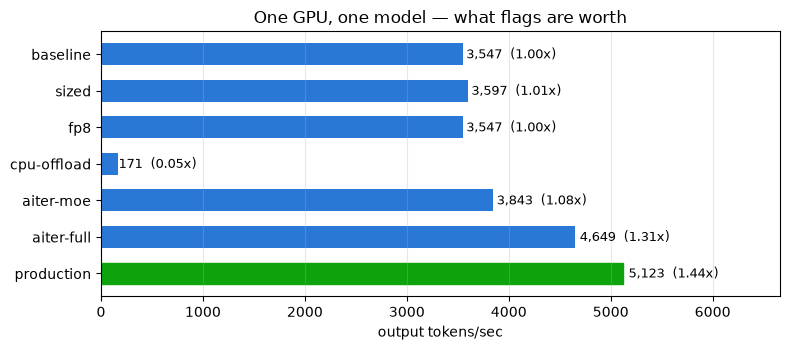

In [50]:
import matplotlib.pyplot as plt
names = [r[0] for r in rows]
vals  = [r[1] for r in rows]
plt.figure(figsize=(8, 3.6))
bars = plt.barh(names, vals, color="#2a78d6", height=0.6)
bars[vals.index(max(vals))].set_color("#0ca30c")
for i, v in enumerate(vals):
    plt.text(v * 1.01, i, f"{v:,.0f}  ({v/base:.2f}x)", va="center", fontsize=9)
plt.gca().invert_yaxis()
plt.xlim(0, max(vals) * 1.3)
plt.xlabel("output tokens/sec")
plt.title("One GPU, one model — what flags are worth")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## The command to take home

```bash
docker run -d --rm --name vllm-server \
    --network host --ipc host \
    --device /dev/kfd --device /dev/dri \
    --group-add video --group-add render \
    --shm-size 16g \
    -e HIP_VISIBLE_DEVICES=0 \
    -v ~/.cache/huggingface:/root/.cache/huggingface \
    -e VLLM_ROCM_USE_AITER=1 \
    --entrypoint '' \
    rocm/vllm:latest \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --port 8000 \
        --attention-backend ROCM_AITER_UNIFIED_ATTN \
        --moe-backend aiter \
        --linear-backend aiter \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92 \
        --kv-cache-dtype fp8 \
        --speculative-config '{"method":"ngram","num_speculative_tokens":5,"prompt_lookup_max":4}' \
        --enable-auto-tool-choice --tool-call-parser hermes \
        --reasoning-parser qwen3
```

## What we skipped

**We never checked whether we broke anything.** Two changes here are lossy — FP8 weights, and more so
the FP8 KV cache. Speculative decoding isn't; quantization is. Before this goes to production, run an
accuracy harness across bf16 → FP8 → FP8+FP8-KV and decide if the delta is acceptable for your task.
A 2× throughput win you can't defend on quality isn't a win.

**Anything needing a second GPU:** tensor parallelism, expert parallelism (a natural fit for this MoE),
data-parallel replicas, prefill/decode disaggregation. That's the next talk.

**Also left out:** Triton MoE autotuning, structured outputs (JSON-schema-constrained decoding), LoRA
hot-swapping, and deliberately starving the KV cache to watch `num_preemptions` climb — the best way
to learn what a saturated vLLM server looks like before you meet one at 3am.

In [51]:
# Free the GPU when you're done.
!docker logs vllm-server > logs/07-production.log 2>&1; docker rm -f vllm-server

vllm-server
